In [1]:
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load ddG results

In [2]:
def parse_ddg_file(path):
    """Parse a cartesian_ddg .ddg file.
    Returns ddg = mean(MUT scores) - mean(WT scores).
    """
    wt_scores, mut_scores = [], []
    with open(path) as f:
        for line in f:
            tokens = line.split()
            if len(tokens) < 4:
                continue
            label = tokens[2]  # e.g. 'WT_:' or 'MUT_30TRP:'
            score = float(tokens[3])
            if label.startswith('WT_'):
                wt_scores.append(score)
            elif label.startswith('MUT_'):
                mut_scores.append(score)
    return np.mean(mut_scores) - np.mean(wt_scores)


rows = []
for path in glob.glob('results/ddg/*/*/*/*.ddg'):
    # path: results/ddg/{ef}/{design}/{mutation}/{design}_{mutation}.ddg
    parts = path.split('/')
    ef = parts[2]
    design = parts[3]
    mutation = parts[4]
    m = re.match(r'([A-Z])(\d+)([A-Z])', mutation)
    wt_aa, site_n, mut_aa = m.group(1), int(m.group(2)), m.group(3)
    ddg = parse_ddg_file(path)
    rows.append(dict(energy_func=ef, design=design, mutation=mutation,
                     wt_aa=wt_aa, site_n=site_n, mut_aa=mut_aa, ddg=ddg))

ddg_df = pd.DataFrame(rows)
print(f"{len(ddg_df)} ddG values loaded")

64 ddG values loaded


In [3]:
# Join with mutation metadata to get size_change category
meta = pd.read_csv('results/rescue_mutations.csv')
meta = meta[meta['size_change'].isin(['large-to-small', 'small-to-large'])]

df = ddg_df.merge(
    meta[['parent_name', 'wt_aa', 'site_n', 'mut_aa', 'size_change']],
    left_on=['design', 'wt_aa', 'site_n', 'mut_aa'],
    right_on=['parent_name', 'wt_aa', 'site_n', 'mut_aa'],
    how='left'
).drop(columns='parent_name')

df = df[df['mutation'] != 'L5P']

print(df.groupby(['energy_func', 'size_change']).size().to_string())
df.head()

energy_func  size_change   
beta_jan25   large-to-small     7
             small-to-large    24
beta_nov16   large-to-small     7
             small-to-large    24


,energy_func,design,mutation,wt_aa,site_n,mut_aa,ddg,size_change
0,beta_nov16,HHH_rd4_0068,V30F,V,30,F,14.6634,small-to-large
1,beta_nov16,HHH_rd4_0068,V21A,V,21,A,3.2102,large-to-small
2,beta_nov16,HHH_rd4_0068,V30W,V,30,W,18.9186,small-to-large
3,beta_nov16,HHH_rd4_0636,V12A,V,12,A,3.2180,large-to-small
4,beta_nov16,HHH_rd4_0636,V12Y,V,12,Y,1.7406,small-to-large


## ddG distributions by energy function and mutation category

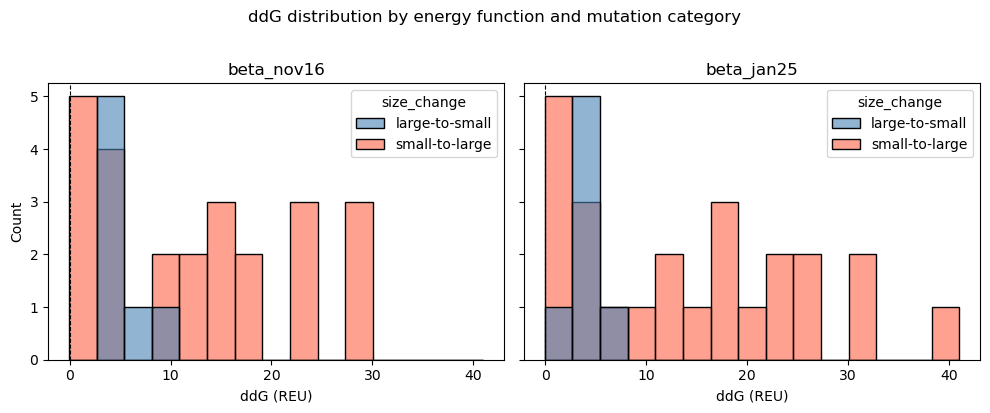

In [4]:
energy_funcs = df['energy_func'].unique()
categories = ['large-to-small', 'small-to-large']
palette = {'large-to-small': 'steelblue', 'small-to-large': 'tomato'}

# Compute shared bin edges across both energy functions
bin_edges = np.histogram_bin_edges(df['ddg'], bins=15)

fig, axes = plt.subplots(1, len(energy_funcs), figsize=(10, 4), sharey=True)

for ax, ef in zip(axes, energy_funcs):
    sub = df[df['energy_func'] == ef]
    sns.histplot(
        data=sub, x='ddg', hue='size_change',
        hue_order=categories, palette=palette,
        bins=bin_edges, alpha=0.6, ax=ax
    )
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(ef)
    ax.set_xlabel('ddG (REU)')

axes[0].set_ylabel('Count')
fig.suptitle('ddG distribution by energy function and mutation category', y=1.02)
plt.tight_layout()
plt.show()

## Scatter: beta_nov16 vs beta_jan25 ddG

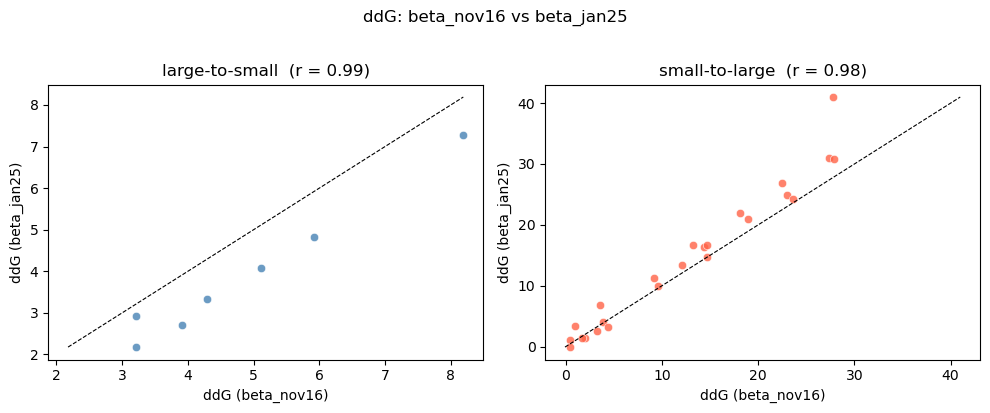

In [5]:
# Pivot so each mutation has one row with a ddG column per energy function
pivot = df.pivot_table(
    index=['design', 'mutation', 'size_change'],
    columns='energy_func',
    values='ddg'
).reset_index()

ef1, ef2 = 'beta_nov16', 'beta_jan25'

fig, axes = plt.subplots(1, len(categories), figsize=(10, 4))

for ax, cat in zip(axes, categories):
    sub = pivot[pivot['size_change'] == cat]
    sns.scatterplot(data=sub, x=ef1, y=ef2, color=palette[cat], alpha=0.8, ax=ax)

    lims = [min(sub[ef1].min(), sub[ef2].min()), max(sub[ef1].max(), sub[ef2].max())]
    ax.plot(lims, lims, 'k--', linewidth=0.8)

    r = sub[[ef1, ef2]].corr().iloc[0, 1]
    ax.set_title(f'{cat}  (r = {r:.2f})')
    ax.set_xlabel(f'ddG ({ef1})')
    ax.set_ylabel(f'ddG ({ef2})')

fig.suptitle('ddG: beta_nov16 vs beta_jan25', y=1.02)
plt.tight_layout()
plt.show()

In [6]:
for cat in categories:
    print(f'\n{cat}')
    sub = pivot[pivot['size_change'] == cat][['design', 'mutation', ef1, ef2]].copy()
    sub['diff (jan25 - nov16)'] = sub[ef2] - sub[ef1]
    sub = sub.sort_values('diff (jan25 - nov16)').reset_index(drop=True)
    display(sub)


large-to-small


energy_func,design,mutation,beta_nov16,beta_jan25,diff (jan25 - nov16)
0,HHH_rd4_0284,V21A,3.9144,2.7072,-1.2072
1,HHH_rd4_0216,V11G,5.9218,4.8350,-1.0868
2,HHH_rd4_0216,I21A,5.1158,4.0796,-1.0362
3,HHH_rd4_0068,V21A,3.2102,2.1772,-1.0330
4,HHH_rd4_0628,V21A,4.2930,3.3214,-0.9716
5,HHH_rd4_0284,V21G,8.1902,7.2708,-0.9194
6,HHH_rd4_0636,V12A,3.2180,2.9212,-0.2968



small-to-large


energy_func,design,mutation,beta_nov16,beta_jan25,diff (jan25 - nov16)
0,HHH_rd4_0998,V11F,4.3522,3.2574,-1.0948
1,HHH_rd4_0628,V30Y,3.2132,2.5478,-0.6654
2,HHH_rd4_0998,V30F,0.4298,-0.0686,-0.4984
3,HHH_rd4_0636,V12W,1.9590,1.4922,-0.4668
4,HHH_rd4_0636,V12Y,1.7406,1.4144,-0.3262
5,HHH_rd4_0068,V30F,14.6634,14.6636,0.0002
6,EHEE_rd4_0144,A15W,3.8788,4.1016,0.2228
7,EHEE_rd4_0144,G8M,9.6136,9.8996,0.2860
8,HHH_rd4_0284,A9L,23.6520,24.2320,0.5800
9,EEHEE_rd4_0215,A18M,0.4860,1.1032,0.6172
